In [125]:
import json
import pandas as pd
import re
import numpy as np

with open('games.json', encoding="utf8") as file:
    d=json.loads(file.read())

new_games_df = pd.DataFrame.from_dict(d).T.drop(['affiliate_links', 'backloggd_link', 'content', 'submitted_by', 'twitter_ids'], axis=1)
new_games_df["game"] = new_games_df['answers'].apply(lambda x: x[0])
new_games_df = new_games_df.drop(['answers'], axis=1)

def clear_platforms(x):
    x = re.sub(r'\(.*\)', '', x)
    if x.startswith('2020: PC'):
        return ['PC']
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip() for s in x]
    x = ["PS1" if s == "PS" else s for s in x]
    x = ["X360" if s == "360" else s for s in x]
    x = ["GameCube" if s == "Gamecube" else s for s in x]
    x = ["Xbox Series" if s == "X Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Xbox series" else s for s in x]
    x = ["Mac" if s == "Macintosh" else s for s in x]
    return x

new_games_df["console_platform"] = new_games_df["console_platform"].apply(clear_platforms)

def clear_genres(x):
    x = re.sub(r'\(.*\)', '', x)
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip().casefold() for s in x]
    return x

new_games_df["genre"] = new_games_df["genre"].apply(clear_genres)

def clear_metacritic(x):
    if x and x[0].isalpha():
        return None
    x = re.search(r"[0-9]+", x)
    return x.group(0)

new_games_df["metacritic_score"] = new_games_df["metacritic_score"].apply(clear_metacritic)
new_games_df["metacritic_score"] = new_games_df["metacritic_score"].astype(float)

new_games_df["release_year"] = new_games_df["release_year"].apply(lambda x: re.search(r"[0-9]{4}", x).group(0))
new_games_df["release_year"] = new_games_df["release_year"].astype(int)

new_games_df["day"] = new_games_df.index.astype(int)
new_games_df = new_games_df.set_index('day')

# Compute

In [127]:
# import results
f01 = open("gtg-februar26.txt", "r", encoding="utf8").read()

fulltext = '\n'.join([f01])

# specify beggining and end
from_day = 1359
to_day = 1386

fulltext = fulltext.replace("\n\n —", " —") # fix for new Discord badges


pasted = re.findall(".* — [^#—]+#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}|#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)
pasted_all = re.findall("#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)

df = pd.DataFrame(pasted, columns=['full'])
df['name'] = df['full'].apply(lambda x: x.split(" — ")[0].strip()  if "—" in x else None)

df['day'] = df['full'].apply(lambda x: re.findall("#[0-9]+", x)[0][1:])
df['day'] = df['day'].astype(int)

#df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)
df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else 5.5 if "🟨" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)

df['score'] = ((df['guess']) * -1) + 6
df['score'].loc[np.isnan(df['score'])] = 0

df['days played'] = 1

df['guess'] = df['guess'] + 1

df['guess'].loc[np.isnan(df['guess'])] = 7

df = df.ffill()

df = df[(df.day >= from_day) & (df.day <= to_day)]

# TODO: assert there are no duplicates

difficulty_index = df.groupby(['day']).agg({'score':'sum'}).sort_values(by='score')
difficulty_index = difficulty_index.rename(columns={"score": "day_difficulty"})
difficulty_index_copy = difficulty_index.copy()
difficulty_index_copy.loc[difficulty_index_copy["day_difficulty"] == 0, "day_difficulty"] = 1.0

df = df.join(difficulty_index_copy, on='day')

df['AW hipster score'] = (df['score'] / df['day_difficulty'] * 100).astype(int)

df = df.join(new_games_df, on='day')

df['decade'] = df['release_year'].apply(lambda x: x // 10 * 10)

df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
#df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"]
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess
1,yablko,98.0,25,3.08
2,Joey Vancouver,84.5,28,3.98
3,boomer,84.0,28,4.00
4,Hades🐍,82.0,28,4.07
5,HusKy,74.5,28,4.34
6,hostinko,71.5,28,4.45
7,Tulex,71.5,27,4.35
8,Mako,67.0,28,4.61
9,Naga,62.0,28,4.79
10,Shape1ess,60.5,27,4.76


In [128]:
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 255)

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

hipster_score_2 = df.copy().groupby(['name','AW hipster score'])['game'].apply(lambda x: '\n'.join(x)).reset_index().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])
hipster_score_2.index = np.arange(len(hipster_score_2)) + 1
pretty_print(hipster_score_2[hipster_score_2["AW hipster score"] > 0])

,name,AW hipster score,game
1,HusKy,50,Core Keeper
2,Naga,27,Kunitsu-Gami: Path of the Goddess
3,yablko,27,Kunitsu-Gami: Path of the Goddess
4,Tulex,25,Shinobi: Art of VengeanceCore Keeper
5,boomer,25,Shinobi: Art of Vengeance
6,kronoss,25,Core Keeper
7,Mako,20,Tchia
8,hostinko,20,Tchia
9,Hades🐍,18,Ace Combat 7: Skies Unknown
10,Joey Vancouver,18,Call of Duty: Black Ops 6


In [129]:
hipster_score = df.copy().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])[['name', 'day', 'guess', 'AW hipster score']]
hipster_score['day'] = hipster_score['day'].astype("Int64")
hipster_score["guess"] = hipster_score["guess"].astype(int)
hipster_score = hipster_score.join(new_games_df[['game', 'release_year']], on='day')
hipster_score['AW hipster score'] = hipster_score['AW hipster score'].round(2)
hipster_score.index = range(len(hipster_score))
hipster_score.index += 1
hipster_score

,name,day,guess,AW hipster score,game,release_year
1,HusKy,1386,3,50,Core Keeper,2022
2,Naga,1372,2,27,Kunitsu-Gami: Path of the Goddess,2024
3,yablko,1372,2,27,Kunitsu-Gami: Path of the Goddess,2024
4,Tulex,1366,5,25,Shinobi: Art of Vengeance,2025
5,boomer,1366,5,25,Shinobi: Art of Vengeance,2025
6,kronoss,1386,5,25,Core Keeper,2022
7,Mako,1380,4,20,Tchia,2023
8,hostinko,1380,4,20,Tchia,2023
9,Hades🐍,1374,1,18,Ace Combat 7: Skies Unknown,2019
10,Joey Vancouver,1381,1,18,Call of Duty: Black Ops 6,2024


In [130]:
difficulty_index.join(new_games_df['game'], on='day').head(5)

,day_difficulty,game
day,,
1365,0.0,Cory in the House
1386,8.0,Core Keeper
1366,8.0,Shinobi: Art of Vengeance
1380,15.0,Tchia
1371,16.0,Super Mario Party Jamboree


In [131]:
difficulty_index.join(new_games_df['game'], on='day').sort_values(by='day_difficulty', ascending=False).head(5)

,day_difficulty,game
day,,
1367,73.5,Fallout: New Vegas
1373,71.0,SuperHot
1378,67.0,Fall Guys
1377,67.0,Quake II
1385,59.5,Gran Turismo 3: A-Spec


In [132]:
points = [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]

df_rankings = df_final[['name', 'total score']].merge(hipster_score_2[['name', 'AW hipster score']], on='name', how='outer')
df_rankings["total score points"] = 0
df_rankings["hipster score points"] = 0

for i, winner in enumerate(df_final.head(10).name):
    df_rankings.loc[df_rankings.name == winner, 'total score points'] = points[i]

for i in range(len(df_rankings) - 1):
    if df_rankings.loc[i, 'total score'] == df_rankings.loc[i+1, 'total score']:
        df_rankings.loc[i+1, 'total score points'] = df_rankings.loc[i, 'total score points']

for i, winner in enumerate(hipster_score_2.head(3).name):
    df_rankings.loc[df_rankings.name == winner, 'hipster score points'] = points[-3+i]

df_rankings = df_rankings.sort_values(by=['AW hipster score', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()

# override for hipster score points
for i in range(len(df_rankings) - 1):
   if df_rankings.loc[i, 'AW hipster score'] == df_rankings.loc[i+1, 'AW hipster score']:
       df_rankings.loc[i+1, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])
       df_rankings.loc[i, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])

df_rankings['final points'] = df_rankings['total score points'] + df_rankings['hipster score points']
df_rankings = df_rankings.sort_values(by=['final points', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()
df_rankings = df_rankings.drop(columns='index')
df_rankings.index += 1
df_rankings[df_rankings["final points"] > 0][['name', 'total score points', 'hipster score points', 'final points']]

,name,total score points,hipster score points,final points
1,yablko,25,2,27
2,Joey Vancouver,18,0,18
3,boomer,15,0,15
4,HusKy,10,4,14
5,Hades🐍,12,0,12
6,Tulex,8,0,8
7,hostinko,8,0,8
8,Mako,4,0,4
9,Naga,2,2,4
10,Shape1ess,1,0,1


In [133]:
df_rankings[df_rankings["final points"] > 0][['name', 'final points']]

,name,final points
1,yablko,27
2,Joey Vancouver,18
3,boomer,15
4,HusKy,14
5,Hades🐍,12
6,Tulex,8
7,hostinko,8
8,Mako,4
9,Naga,4
10,Shape1ess,1


In [137]:
rankings_year = pd.read_csv("points2026.csv")
rankings_year = rankings_year.drop(["Unnamed: 0"], axis=1)
rankings_year

rankings_year.drop(["february"], axis=1, inplace=True)
rankings_year

#rankings_year = df_rankings[df_rankings["final points"] > 0][['name', 'final points']]
#rankings_year["total"] = rankings_year["final points"]

,name,january,total
0,Hades🐍,27,39
1,boomer,18,33
2,yablko,6,33
3,HusKy,15,29
4,Joey Vancouver,4,22
5,hostinko,10,18
6,eniac,12,12
7,Tulex,1,9
8,kronoss,8,9
9,Naga,0,6


In [138]:
rankings_year = rankings_year.merge(df_rankings[df_rankings["final points"] > 0][['name', 'final points']], on='name', how='outer')
rankings_year = rankings_year.fillna(value = 0)
rankings_year = rankings_year.rename(columns={"final points": "february"})
rankings_year = rankings_year[[c for c in rankings_year if c not in ['total']] + ['total']]

rankings_year.iloc[:, 1:-1] = rankings_year.iloc[:, 1:-1].astype(int)
rankings_year['total'] = rankings_year.iloc[:, 1:-1].sum(axis=1)
rankings_year = rankings_year.sort_values(by='total', ascending=False).reset_index()
rankings_year = rankings_year.drop(columns='index')
rankings_year.index += 1
rankings_year

,name,january,february,total
1,Hades🐍,27,12,39
2,boomer,18,15,33
3,yablko,6,27,33
4,HusKy,15,14,29
5,Joey Vancouver,4,18,22
6,hostinko,10,8,18
7,eniac,12,0,12
8,Tulex,1,8,9
9,kronoss,8,0,8
10,Naga,0,4,4


In [139]:
rankings_year.to_csv("points2026.csv")

In [140]:
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]
cumulative

,january,february,name
1,27,39,Hades🐍
2,18,33,boomer
3,6,33,yablko
4,15,29,HusKy
5,4,22,Joey Vancouver
6,10,18,hostinko
7,12,12,eniac
8,1,9,Tulex
9,8,8,kronoss
10,0,4,Naga


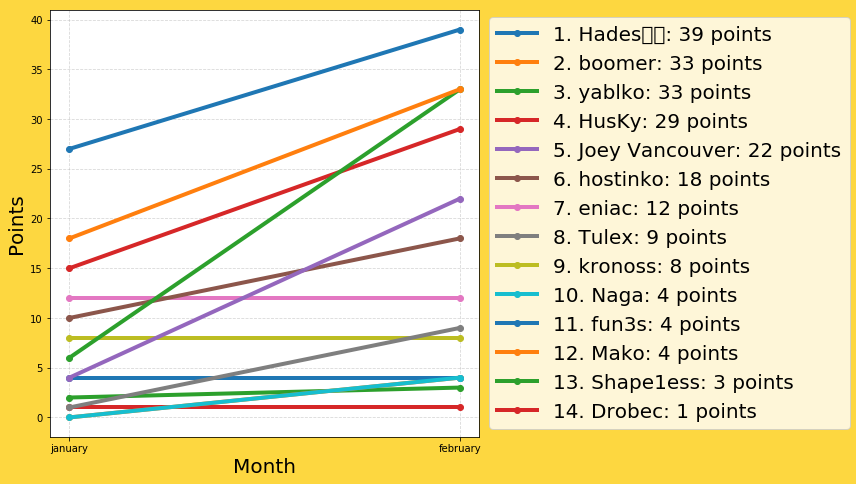

In [142]:
import matplotlib.pyplot as plt
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#fdd740")

for i, row in cumulative.iterrows():
    ax.plot(rankings_year.iloc[:, 1:-1].columns, row.values[0:-1], 'o-', label=f"{i}. {row['name']}: {row.values[-2]} points", linewidth=4, zorder=100-i)
    # Annotate name at the last point
    #plt.text(x=4.3, y=row.values[-2], s=row['name'],
    #         va='center', ha='left', fontsize=12)
    
#names_points = cumulative.groupby(cumulative.columns[-2])['name'].agg(', '.join).reset_index()
#for i, row in names_points.iterrows():
#    plt.text(x=1.1, y=row.values[-2], s=row['name'] + f": {row.values[-2]}",
#             va='center', ha='left', fontsize=12, rotation=0, rotation_mode='anchor')

#plt.title('Arcade Watch GtG League Points Over Time')
plt.xlabel('Month', fontsize=20)
plt.ylabel('Points', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
plt.tight_layout()
plt.show()